## Data Preprocessing

In [1]:
library(phyloseq)
library(biomformat)
library(ggplot2)
library(vegan)
library(limma)
library(edgeR)
library(pheatmap)
library(DESeq2)
library(dplyr)
library(readr)
library(tidyr)

Loading required package: permute

Loading required package: lattice

This is vegan 2.6-8

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:biomformat’:

    colnames, rownames


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked 

In [2]:
# Load the pathabundance data
pathabundance_file <- "/home/gamorten/Microbiome_Health/data/cleaned_pathabundance_table.tsv"
pathabundance <- read_tsv(pathabundance_file)

# Preview the data
print(head(pathabundance))


Rows: 491 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (1): # Pathway
dbl (73): S00JD-0001, S00JD-0002, S00JD-0003, S00JD-0004, S00JD-0005, S00JD-...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 6 × 74
  `# Pathway`   `S00JD-0001` `S00JD-0002` `S00JD-0003` `S00JD-0004` `S00JD-0005`
  <chr>                <dbl>        <dbl>        <dbl>        <dbl>        <dbl>
1 UNMAPPED          0.193        0.196      0.184          0.150        0.170   
2 UNINTEGRATED      0.764        0.765      0.770          0.800        0.791   
3 12DICHLORETH…     0            0          0.00000303     0            0       
4 1CMET2-PWY: …     0.000388     0.000335   0.000298       0.000356     0.000322
5 3-HYDROXYPHE…     0            0          0.00000482     0            0       
6 AEROBACTINSY…     0            0          0              0            0       
# ℹ 68 more variables: `S00JD-0006` <dbl>, `S00JD-0007` <dbl>,
#   `S00JD-0008` <dbl>, `S00JD-0009` <dbl>, `S00JD-0010` <dbl>,
#   `S00JD-0011` <dbl>, `S00JD-0012` <dbl>, `S00JD-0013` <dbl>,
#   `S00JD-0014` <dbl>, `S00JD-0015` <dbl>, `S00JD-0016` <dbl>,
#   `S00JD-0017` <dbl>, `S00JD-0018` <dbl>, `S00JD-0019` <dbl>,
#   `S00JD-002

In [3]:
pathabundance_filtered <- pathabundance %>%
  filter(!`# Pathway` %in% c("UNMAPPED", "UNINTEGRATED"))

# Step 3: Convert All Columns (Except Pathway Names) to Numeric
# Store pathway names in a separate column for reference
pathways <- pathabundance_filtered$`# Pathway`
print(pathways)

pathabundance_filtered <- as.data.frame(pathabundance_filtered)
rownames(pathabundance_filtered) <- pathways
# Use `mutate_if(is.character, as.numeric)` to convert all numeric-like columns properly
pathabundance_filtered <- pathabundance_filtered %>%
  select(-`# Pathway`) %>%
  mutate_all(as.numeric) %>%
  as.data.frame()

# Check the structure of the dataset
str(pathabundance_filtered)

# Check for NA values in the taxonomic table
na_count <- sum(is.na(pathabundance_filtered ))
print(paste("Number of NA values in the taxonomic table:", na_count))

# Check for NA values column-wise
na_by_column <- colSums(is.na(pathabundance_filtered ))
print("Number of NA values in each column of the taxonomic table:")
print(na_by_column)


  [1] "12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation"                                                           
  [2] "1CMET2-PWY: folate transformations III (E. coli)"                                                              
  [3] "3-HYDROXYPHENYLACETATE-DEGRADATION-PWY: 4-hydroxyphenylacetate degradation"                                    
  [4] "AEROBACTINSYN-PWY: aerobactin biosynthesis"                                                                    
  [5] "ALLANTOINDEG-PWY: superpathway of allantoin degradation in yeast"                                              
  [6] "ANAEROFRUCAT-PWY: homolactic fermentation"                                                                     
  [7] "ANAGLYCOLYSIS-PWY: glycolysis III (from glucose)"                                                              
  [8] "ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis"                                        
  [9] "ARGDEG-PWY: superpathway of L-arginine, p

In [4]:
# Load metadata
metadata_file <- "/home/gamorten/Microbiome_Health/metadata/metadata.csv"  # Replace with your actual metadata CSV file path
metadata <- read_csv(metadata_file)

# Ensure that metadata and pathabundance data align
# Assuming metadata has a column named 'sample' that corresponds to the column names of pathabundance data
# Assuming metadata also has a 'group' column that specifies the group for each sample
colnames(pathabundance_filtered) <- metadata$`MBI Sample ID`  # Make sure column names match metadata sample names

# Convert 'group' to a factor
metadata$Group <- as.factor(metadata$Group)

# Verify metadata structure and alignment
print(metadata)


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 73 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): MBI Sample ID, Subject ID, Sampling Date, Sample Type, Group, Race...
dbl  (8): Specimen ID, Tobacco Use, BMI, Consent Age, Batch, Stool_Count, De...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 73 × 24
   `MBI Sample ID` `Subject ID` `Specimen ID` `Sampling Date` `Sample Type`
   <chr>           <chr>                <dbl> <chr>           <chr>        
 1 S00NO-0001      HMC-01-1006        4511679 4/18/2019       Human feces  
 2 S00NO-0002      HMC-01-2006        4589482 5/23/2019       Human feces  
 3 S00NO-0003      HMC-01-1032        4624890 6/14/2019       Human feces  
 4 S00NO-0004      HMC-01-1053        4663038 7/3/2019        Human feces  
 5 S00NO-0005      HMC-01-1074        4855634 10/8/2019       Human feces  
 6 S00NO-0006      HMC-01-1072        4860125 10/9/2019       Human feces  
 7 S00NO-0007      HMC-01-1020        4398870 3/4/2019        Human feces  
 8 S00NO-0008      HMC-01-1018        4413541 3/12/2019       Human feces  
 9 S00NO-0009      HMC-01-1171        5981029 9/30/2021       Human feces  
10 S00NO-0010      HMC-01-1028        4476537 4/5/2019        Human feces  
# ℹ 63 more rows
# ℹ 19 more variables: Group <fct>, Race <chr>, `To

In [ ]:
# Create the design matrix for limma
design <- model.matrix(~ 0 + metadata$Group)
colnames(design) <- levels(metadata$Group)

# Print the design matrix to verify
print(design)


   Case Control
1     0       1
2     1       0
3     0       1
4     0       1
5     0       1
6     0       1
7     0       1
8     0       1
9     0       1
10    0       1
11    0       1
12    0       1
13    0       1
14    1       0
15    1       0
16    1       0
17    1       0
18    1       0
19    1       0
20    1       0
21    1       0
22    1       0
23    1       0
24    1       0
25    1       0
26    1       0
27    1       0
28    1       0
29    1       0
30    1       0
31    1       0
32    1       0
33    1       0
34    1       0
35    1       0
36    1       0
37    1       0
38    1       0
39    1       0
40    1       0
41    1       0
42    1       0
43    1       0
44    1       0
45    1       0
46    1       0
47    1       0
48    1       0
49    1       0
50    1       0
51    1       0
52    1       0
53    1       0
54    1       0
55    0       1
56    0       1
57    0       1
58    0       1
59    0       1
60    0       1
61    0       1
62    0 

In [6]:
# Convert the pruned dataset to a numeric matrix
pathabundance_matrix <- as.matrix(pathabundance_filtered)

fit <- lmFit(pathabundance_matrix, design)

# Create a contrast matrix to compare "Case" vs "Control"
contrast_matrix <- makeContrasts(Case - Control, levels = design)

# Apply the contrasts to the fitted model
fit2 <- contrasts.fit(fit, contrast_matrix)

# Apply empirical Bayes moderation
fit2 <- eBayes(fit2)

# Extract Significant Pathways
top_pathways <- topTable(fit2, adjust.method = "BH", number = Inf)

# Add the pathway names back to the results
# Since row names in `top_pathways` should match with the original pathways vector
top_pathways$Pathway <- rownames(top_pathways)

# Reorder the columns to have Pathway as the first column
top_pathways <- top_pathways %>%
  select(Pathway, everything())

# View the updated top pathways with pathway names
print(head(top_pathways))


                                                                                                                                    Pathway
TRPSYN-PWY: L-tryptophan biosynthesis                                                                 TRPSYN-PWY: L-tryptophan biosynthesis
PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing) PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing)
PWY-6703: preQ0 biosynthesis                                                                                   PWY-6703: preQ0 biosynthesis
PWY-5695: inosine 5'-phosphate degradation                                                       PWY-5695: inosine 5'-phosphate degradation
METH-ACETATE-PWY: methanogenesis from acetate                                                 METH-ACETATE-PWY: methanogenesis from acetate
PANTO-PWY: phosphopantothenate biosynthesis I                                                 PANTO-PWY: phosphopantothenate biosynthesis I
                    

In [ ]:
# Extract the top 10 pathways based on the adjusted p-value
top10_pathways <- top_pathways %>% 
  arrange(adj.P.Val) %>%  # Sort by adjusted p-value
  head(10)

# Preview the top 10 pathways to verify
print(top10_pathways)


                                                                                                                                      Pathway
TRPSYN-PWY: L-tryptophan biosynthesis                                                                   TRPSYN-PWY: L-tryptophan biosynthesis
PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing)   PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing)
PWY-6703: preQ0 biosynthesis                                                                                     PWY-6703: preQ0 biosynthesis
PWY-5695: inosine 5'-phosphate degradation                                                         PWY-5695: inosine 5'-phosphate degradation
METH-ACETATE-PWY: methanogenesis from acetate                                                   METH-ACETATE-PWY: methanogenesis from acetate
PANTO-PWY: phosphopantothenate biosynthesis I                                                   PANTO-PWY: phosphopantothenate biosynthesis I
PWY-65

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


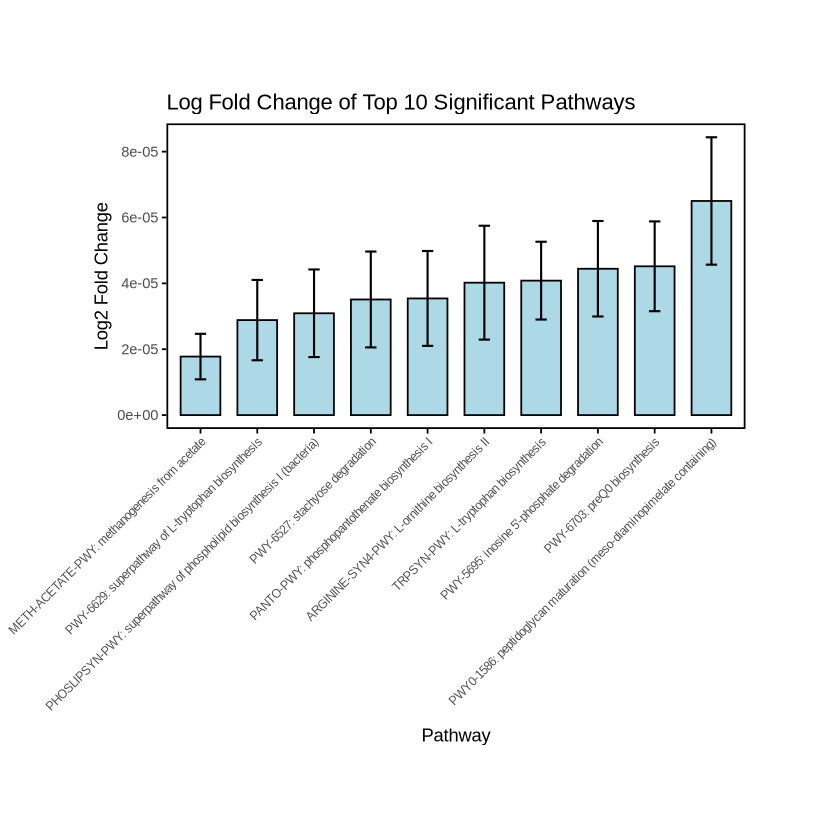

In [8]:
# Load ggplot2 for plotting
library(ggplot2)

# If lfcSE is not available in limma output, use the standard deviation or approximate value for error bars.
# Calculate the standard error (we will use |logFC| divided by |t-statistic| as an approximation)
top10_pathways$lfcSE <- abs(top10_pathways$logFC) / abs(top10_pathways$t)

# Create the waterfall plot for the top significant pathways
ggplot(top10_pathways, aes(x = reorder(Pathway, logFC), y = logFC, fill = logFC > 0)) +
  geom_bar(stat = "identity", color = "black", width = 0.7) +
  geom_errorbar(aes(ymin = logFC - lfcSE, ymax = logFC + lfcSE), 
                width = 0.2, color = "black", size = 0.6) +
  # Customize the fill color for positive and negative log2 fold changes
  scale_fill_manual(values = c("lightblue", "salmon"), labels = c("Decreased", "Increased")) +
  # Add plot labels and theme customization
  labs(title = "Log Fold Change of Top 10 Significant Pathways",
       x = "Pathway",
       y = "Log2 Fold Change",
       fill = "Direction of Change") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),  # Remove gridlines
    panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
    legend.position = "none",  # Remove legend
    axis.ticks.x = element_line(color = "black", size = 0.5),
    axis.ticks.y = element_line(color = "black", size = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  ) +
  theme(plot.margin = margin(2, 2, 2, 2, "cm"))


      Sample
1 S00JD-0001
2 S00JD-0001
3 S00JD-0001
4 S00JD-0001
5 S00JD-0001
6 S00JD-0001
                                                                Pathway
1                                          PWY-6703: preQ0 biosynthesis
2 PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing)
3                   PWY-6629: superpathway of L-tryptophan biosynthesis
4                                 TRPSYN-PWY: L-tryptophan biosynthesis
5                         METH-ACETATE-PWY: methanogenesis from acetate
6                         PANTO-PWY: phosphopantothenate biosynthesis I
    Abundance  Subject ID Specimen ID Sampling Date Sample Type Group  Race
1 3.12083e-04 HMC-01-1007     4597529     5/29/2019 Human feces  Case White
2 4.79598e-04 HMC-01-1007     4597529     5/29/2019 Human feces  Case White
3 3.17398e-04 HMC-01-1007     4597529     5/29/2019 Human feces  Case White
4 2.39494e-04 HMC-01-1007     4597529     5/29/2019 Human feces  Case White
5 9.75304e-05 HMC-01-1007

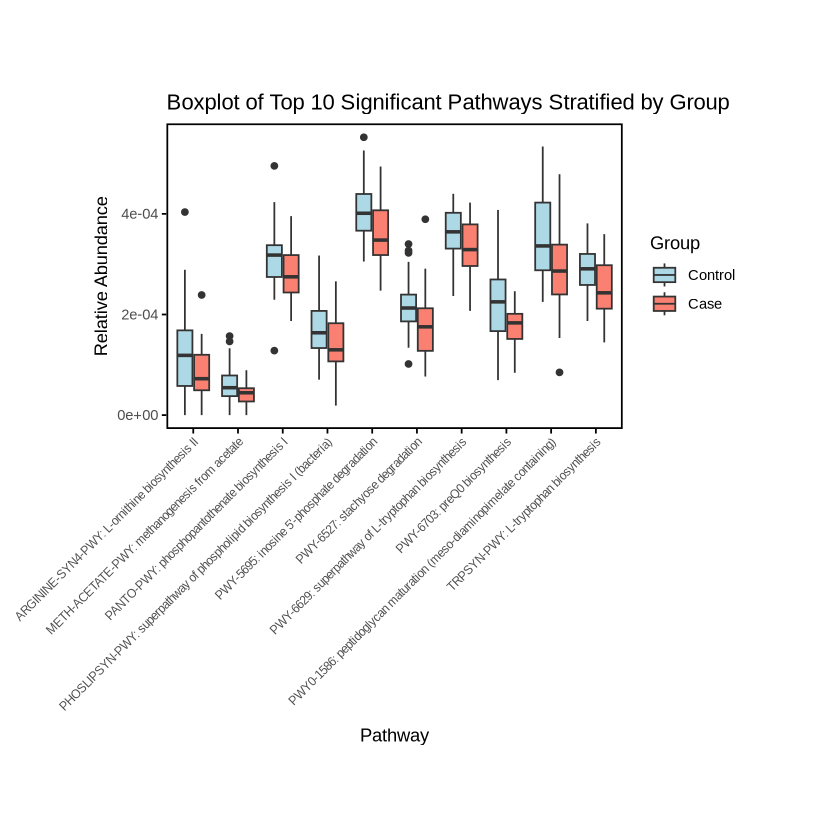

In [9]:
# Extract the pathway names of the top 10 significant pathways
top10_pathway_n   ames <- top10_pathways$Pathway

# Filter the pathabundance_pruned to include only the top 10 significant pathways
pathabundance_top10 <- pathabundance_filtered[rownames(pathabundance_filtered) %in% top10_pathway_names, ]

# Convert pathabundance_top10 to a long format for ggplot2
# Add pathway names as a new column
pathabundance_top10$Pathway <- rownames(pathabundance_top10)


pathabundance_long <- pathabundance_top10 %>%
  pivot_longer(cols = -Pathway, names_to = "Sample", values_to = "Abundance")

# Add group information from metadata
pathabundance_long <- merge(pathabundance_long, metadata, by.x = "Sample", by.y = "MBI Sample ID")

# Verify the merged data
print(head(pathabundance_long))


# Create the boxplot stratified by case and control
ggplot(pathabundance_long, aes(x = Pathway, y = Abundance, fill = Group)) +
  geom_boxplot() +
  # Customize the fill color for Case and Control groups
  scale_fill_manual(values = c("lightblue", "salmon"), labels = c("Control", "Case")) +
  # Add plot labels and theme customization
  labs(title = "Boxplot of Top 10 Significant Pathways Stratified by Group",
       x = "Pathway",
       y = "Relative Abundance",
       fill = "Group") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),
        panel.border = element_rect(color = "black", fill = NA, size = 1),
        legend.position = "right") +
  theme(plot.margin = margin(2, 2, 2, 2, "cm"))


In [ ]:
# Assuming your metadata data frame is named 'metadata'
# Add a new column 'Condition' to categorize each sample
metadata <- metadata %>%
  mutate(Condition = case_when(
    Hypertension == "Yes" ~ "Hypertension",
    GDM == "Yes" ~ "GDM",
    TRUE ~ "Healthy"  # This will categorize samples with neither condition as 'Healthy'
  ))

# Verify the modified metadata
head(metadata)


MBI Sample ID,Subject ID,Specimen ID,Sampling Date,Sample Type,Group,Race,Tobacco Use,BMI,Consent Age,⋯,Delivery_EGA,CA_PretermLabor,PreTerm_Labor_EGA,StillBirth,Preeclampsia_During_Labor,Preeclampsia_At_PP,ca_ld_delivery_type,ca_ld_birth_weight,ca_ld_sex_of_baby,Condition
<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
S00NO-0001,HMC-01-1006,4511679,4/18/2019,Human feces,Control,White,0,24.64,39,⋯,40.0000,No,No,No,No,No,"Vaginal, spontaneous",3508,Female,Healthy
S00NO-0002,HMC-01-2006,4589482,5/23/2019,Human feces,Case,Other,1,37.95,31,⋯,37.2857,Yes,No,No,Yes,No,"Vaginal, spontaneous",3160,Male,Hypertension
S00NO-0003,HMC-01-1032,4624890,6/14/2019,Human feces,Control,White,1,18.63,28,⋯,39.5714,No,No,No,No,No,"Vaginal, spontaneous",3340,Female,Healthy
S00NO-0004,HMC-01-1053,4663038,7/3/2019,Human feces,Control,White,1,27.29,37,⋯,37.2857,No,No,No,No,No,"Vaginal, spontaneous",2712,Female,Healthy
S00NO-0005,HMC-01-1074,4855634,10/8/2019,Human feces,Control,Other,1,20.85,34,⋯,37.4286,No,No,No,No,No,Unplanned cesarean section,3393,Male,Healthy
S00NO-0006,HMC-01-1072,4860125,10/9/2019,Human feces,Control,White,0,25.45,27,⋯,39.4286,No,No,No,No,No,"Vaginal, spontaneous",3081,Male,Healthy


In [11]:
# Define pathways related to GH and GDM based on inferred relevance
pathways_gh <- c("PWY-5690: superpathway of L-arginine, L-ornithine, and putrescine biosynthesis",
                 "PWY-4261: superpathway of glutathione metabolism",
                 "PWY-5100: pyruvate fermentation to acetate and lactate II",
                 "PWY-6121: superpathway of methylglyoxal degradation",
                 "PWY-5022: superpathway of sulfolactate degradation")

pathways_gdm <- c("PWY-5695: superpathway of D-glucose and D-galactose degradation",
                  "PWY-1041: glyoxylate cycle",
                  "PWY-7335: propionate fermentation to propanol I",
                  "PWY-5676: superpathway of hexitol degradation (glucitol/sorbitol)",
                  "PWY-5101: pyruvate fermentation to propionate")

# Combine all pathways of interest
pathways_of_interest <- c(pathways_gh, pathways_gdm)


In [ ]:
# Filter pathabundance_pruned to include only pathways of interest
filtered_data <- pathabundance_filtered[rownames(pathabundance_filtered) %in% pathways_of_interest, ]

# Add pathway names as a new column for easier access
filtered_data$Pathway <- rownames(filtered_data)

# Convert filtered_data to long format for ggplot2
library(tidyr)

filtered_data_long <- filtered_data %>%
  pivot_longer(cols = -Pathway, names_to = "Sample", values_to = "Relative_Abundance")

# Create or update metadata with Condition
# Add a Condition column using case_when
metadata <- metadata %>%
  mutate(Condition = case_when(
    Hypertension == "Yes" ~ "Hypertension",
    GDM == "Yes" ~ "GDM",
    TRUE ~ "Healthy"  # Samples without GH or GDM will be "Healthy"
  ))

# Merge the filtered pathway data with metadata
filtered_data_long <- merge(filtered_data_long, metadata, by.x = "Sample", by.y = "MBI Sample ID")

# Verify the merged data
head(filtered_data_long)


,Sample,Pathway,Relative_Abundance,Subject ID,Specimen ID,Sampling Date,Sample Type,Group,Race,Tobacco Use,⋯,Delivery_EGA,CA_PretermLabor,PreTerm_Labor_EGA,StillBirth,Preeclampsia_During_Labor,Preeclampsia_At_PP,ca_ld_delivery_type,ca_ld_birth_weight,ca_ld_sex_of_baby,Condition
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,S00JD-0001,PWY-5100: pyruvate fermentation to acetate and lactate II,0.000159573,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,36.1429,Yes,Yes,No,No,No,Unplanned cesarean section,2880,Female,Hypertension
2,S00JD-0002,PWY-5100: pyruvate fermentation to acetate and lactate II,0.000266611,HMC-01-1011,4412147,3/11/2019,Human feces,Case,White,1,⋯,37.0000,No,No,No,No,Yes,Scheduled cesarean section,2920,Female,Hypertension
3,S00JD-0003,PWY-5100: pyruvate fermentation to acetate and lactate II,0.000245797,HMC-01-1013,4529333,4/24/2019,Human feces,Case,Black,0,⋯,39.2857,No,No,No,No,No,"Vaginal, spontaneous",3060,Female,Hypertension
4,S00JD-0004,PWY-5100: pyruvate fermentation to acetate and lactate II,0.000120750,HMC-01-1016,4566716,5/8/2019,Human feces,Case,White,0,⋯,40.5714,No,No,No,Yes,No,Unplanned cesarean section,4080,Male,Hypertension
5,S00JD-0005,PWY-5100: pyruvate fermentation to acetate and lactate II,0.000256908,HMC-01-1030,4543267,4/30/2019,Human feces,Case,White,1,⋯,41.1429,No,No,No,No,Yes,Unplanned cesarean section,4170,Female,Healthy
6,S00JD-0006,PWY-5100: pyruvate fermentation to acetate and lactate II,0.000192876,HMC-01-1030,4641682,6/25/2019,Human feces,Case,White,0,⋯,41.1429,No,No,No,No,Yes,Unplanned cesarean section,4170,Female,Healthy


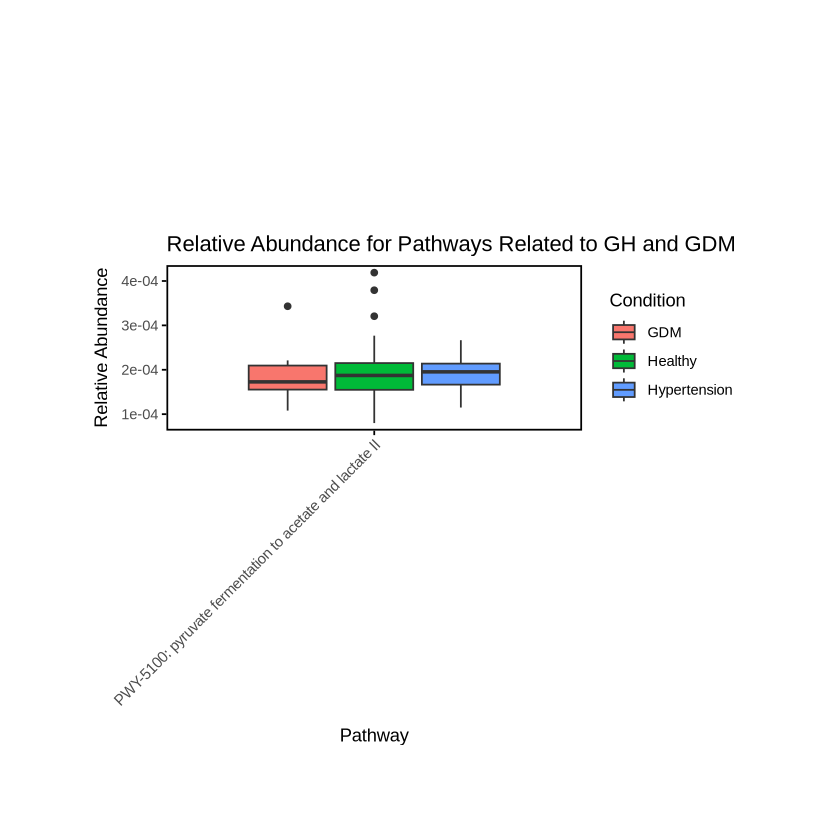

In [13]:
# Load ggplot2 for plotting
library(ggplot2)

# Create the boxplot comparing relative abundance between groups (Hypertension, GDM, Healthy)
ggplot(filtered_data_long, aes(x = Pathway, y = Relative_Abundance, fill = Condition)) +
  geom_boxplot() +
  # Add plot labels and theme customization
  labs(title = "Relative Abundance for Pathways Related to GH and GDM",
       x = "Pathway",
       y = "Relative Abundance",
       fill = "Condition") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        panel.grid = element_blank(),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),
        panel.border = element_rect(color = "black", fill = NA, size = 1),
        legend.position = "right") +
  theme(plot.margin = margin(5,2,2,2, "cm"))


# Correlation Analysis


In [14]:
func_input <- pathabundance_long
tax_input <- read.csv("/home/gamorten/Microbiome_Health/data/taxonomy_correlation_input.csv", header = TRUE, stringsAsFactors = TRUE)
head(func_input)

,Sample,Pathway,Abundance,Subject ID,Specimen ID,Sampling Date,Sample Type,Group,Race,Tobacco Use,⋯,Hypertension,Delivery_EGA,CA_PretermLabor,PreTerm_Labor_EGA,StillBirth,Preeclampsia_During_Labor,Preeclampsia_At_PP,ca_ld_delivery_type,ca_ld_birth_weight,ca_ld_sex_of_baby
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,⋯,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,S00JD-0001,PWY-6703: preQ0 biosynthesis,3.12083e-04,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Yes,36.1429,Yes,Yes,No,No,No,Unplanned cesarean section,2880,Female
2,S00JD-0001,PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing),4.79598e-04,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Yes,36.1429,Yes,Yes,No,No,No,Unplanned cesarean section,2880,Female
3,S00JD-0001,PWY-6629: superpathway of L-tryptophan biosynthesis,3.17398e-04,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Yes,36.1429,Yes,Yes,No,No,No,Unplanned cesarean section,2880,Female
4,S00JD-0001,TRPSYN-PWY: L-tryptophan biosynthesis,2.39494e-04,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Yes,36.1429,Yes,Yes,No,No,No,Unplanned cesarean section,2880,Female
5,S00JD-0001,METH-ACETATE-PWY: methanogenesis from acetate,9.75304e-05,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Yes,36.1429,Yes,Yes,No,No,No,Unplanned cesarean section,2880,Female
6,S00JD-0001,PANTO-PWY: phosphopantothenate biosynthesis I,3.18499e-04,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Yes,36.1429,Yes,Yes,No,No,No,Unplanned cesarean section,2880,Female


In [16]:
corr_input <- merge(func_input,tax_input,by="Sample")
head(corr_input)
write.csv(corr_input, "/home/gamorten/Microbiome_Health/data/functional_input.csv")

,Sample,Pathway,Abundance,Subject ID,Specimen ID,Sampling Date,Sample Type,Group.x,Race,Tobacco Use,⋯,Kingdom,Phylum,Class,Order,Family,Genus,Species,taxa_label,relative_abundance,Group.y
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<fct>
1,S00JD-0001,PWY-6703: preQ0 biosynthesis,0.000312083,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Bacillota,Bacilli,Bacillales,Bacillaceae,Lysinibacillus,agricola,Lysinibacillus agricola,3.3209169,Case
2,S00JD-0001,PWY-6703: preQ0 biosynthesis,0.000312083,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Bacillota,Bacilli,Bacillales,Bacillaceae,Lysinibacillus,fusiformis,Lysinibacillus fusiformis,1.3231830,Case
3,S00JD-0001,PWY-6703: preQ0 biosynthesis,0.000312083,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Bacteroidota,Sphingobacteriia,Sphingobacteriales,Sphingobacteriaceae,Sphingobacterium,sp. UGAL515B_05,Sphingobacterium sp. UGAL515B_05,0.9014451,Case
4,S00JD-0001,PWY-6703: preQ0 biosynthesis,0.000312083,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Bacteroidota,Sphingobacteriia,Sphingobacteriales,Sphingobacteriaceae,Sphingobacterium,lactis,Sphingobacterium lactis,1.0314762,Case
5,S00JD-0001,PWY-6703: preQ0 biosynthesis,0.000312083,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Bacillota,Clostridia,Eubacteriales,Peptococcaceae,Dehalobacterium,formicoaceticum,Dehalobacterium formicoaceticum,1.6496235,Case
6,S00JD-0001,PWY-6703: preQ0 biosynthesis,0.000312083,HMC-01-1007,4597529,5/29/2019,Human feces,Case,White,0,⋯,Bacteria,Bacteroidota,Flavobacteriia,Flavobacteriales,Weeksellaceae,Chryseobacterium,lactis,Chryseobacterium lactis,2.1693636,Case


In [16]:
# Load necessary libraries
library(dplyr)
library(tidyr)

# Step 1: Convert factor columns to character before pivoting
corr_input <- corr_input %>%
  mutate(
    taxa_label = as.character(taxa_label),
    Pathway = as.character(Pathway),
    relative_abundance = as.numeric(as.character(relative_abundance)),
    Abundance = as.numeric(as.character(Abundance))
  ) %>%
  mutate(
    relative_abundance = ifelse(is.na(relative_abundance), 0, relative_abundance),
    Abundance = ifelse(is.na(Abundance), 0, Abundance)
  )

# Step 2: Replace any NA values with 0 for both columns
corr_input <- corr_input %>%
  distinct(Sample, taxa_label, Pathway, .keep_all = TRUE)

# Step 3.1: Pivot wider for taxa abundance
taxa_wide <- corr_input %>%
  select(Sample, taxa_label, relative_abundance) %>%
  pivot_wider(
    names_from = taxa_label,
    values_from = relative_abundance,
    values_fn = sum,  # Use sum or mean to aggregate multiple values if present
    values_fill = 0   # Fill missing values with 0
  )

# Step 3.2: Pivot wider for pathway abundance
pathways_wide <- corr_input %>%
  select(Sample, Pathway, Abundance) %>%
  pivot_wider(
    names_from = Pathway,
    values_from = Abundance,
    values_fn = sum,  # Use sum or mean to aggregate multiple values if present
    values_fill = 0   # Fill missing values with 0
  )

# Step 3.3: Merge taxa and pathway data frames by Sample
combined_wide <- inner_join(taxa_wide, pathways_wide, by = "Sample")

# Extract taxa and pathway data separately for correlation analysis
taxa_columns <- colnames(taxa_wide)[!colnames(taxa_wide) %in% "Sample"]
pathway_columns <- colnames(pathways_wide)[!colnames(pathways_wide) %in% "Sample"]

taxa_matrix <- combined_wide[, taxa_columns]
pathway_matrix <- combined_wide[, pathway_columns]

# Step 4: Calculate Correlation Matrix Between Taxa and Pathways
# Initialize a matrix to store correlation values
pathway_taxa_cor_matrix <- matrix(NA, nrow = ncol(pathway_matrix), ncol = ncol(taxa_matrix),
                                  dimnames = list(colnames(pathway_matrix), colnames(taxa_matrix)))

# Calculate the correlation between each pathway and each taxa
for (i in 1:ncol(pathway_matrix)) {
  for (j in 1:ncol(taxa_matrix)) {
    # Compute Spearman correlation between each pathway and each taxa
    pathway_taxa_cor_matrix[i, j] <- cor(pathway_matrix[, i], taxa_matrix[, j], method = "spearman", use = "pairwise.complete.obs")
  }
}


In [17]:
# Load necessary libraries
library(Hmisc)  # Provides a convenient way to calculate both correlation and p-values

# Calculate correlation matrix with p-values using `Hmisc::rcorr()`
# Flatten the matrices so that pathways and taxa can be correlated together
pathway_matrix <- as.matrix(pathway_matrix)
taxa_matrix <- as.matrix(taxa_matrix)

# Initialize matrices to store correlation values and p-values
cor_matrix <- matrix(NA, nrow = ncol(pathway_matrix), ncol = ncol(taxa_matrix),
                     dimnames = list(colnames(pathway_matrix), colnames(taxa_matrix)))

p_matrix <- matrix(NA, nrow = ncol(pathway_matrix), ncol = ncol(taxa_matrix),
                   dimnames = list(colnames(pathway_matrix), colnames(taxa_matrix)))

# Loop through each combination to calculate correlation and p-value
for (i in 1:ncol(pathway_matrix)) {
  for (j in 1:ncol(taxa_matrix)) {
    cor_result <- cor.test(pathway_matrix[, i], taxa_matrix[, j], method = "spearman", use = "pairwise.complete.obs")
    cor_matrix[i, j] <- cor_result$estimate
    p_matrix[i, j] <- cor_result$p.value
  }
}




Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following object is masked from ‘package:Biobase’:

    contents


The following objects are masked from ‘package:base’:

    format.pval, units


Warning message in cor.test.default(pathway_matrix[, i], taxa_matrix[, j], method = "spearman", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(pathway_matrix[, i], taxa_matrix[, j], method = "spearman", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(pathway_matrix[, i], taxa_matrix[, j], method = "spearman", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(pathway_matrix[, i], taxa_matrix[, j], method = "spearman", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(pathway_matrix[, i], taxa_matrix[, j], method = "spearman", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(pathway_mat

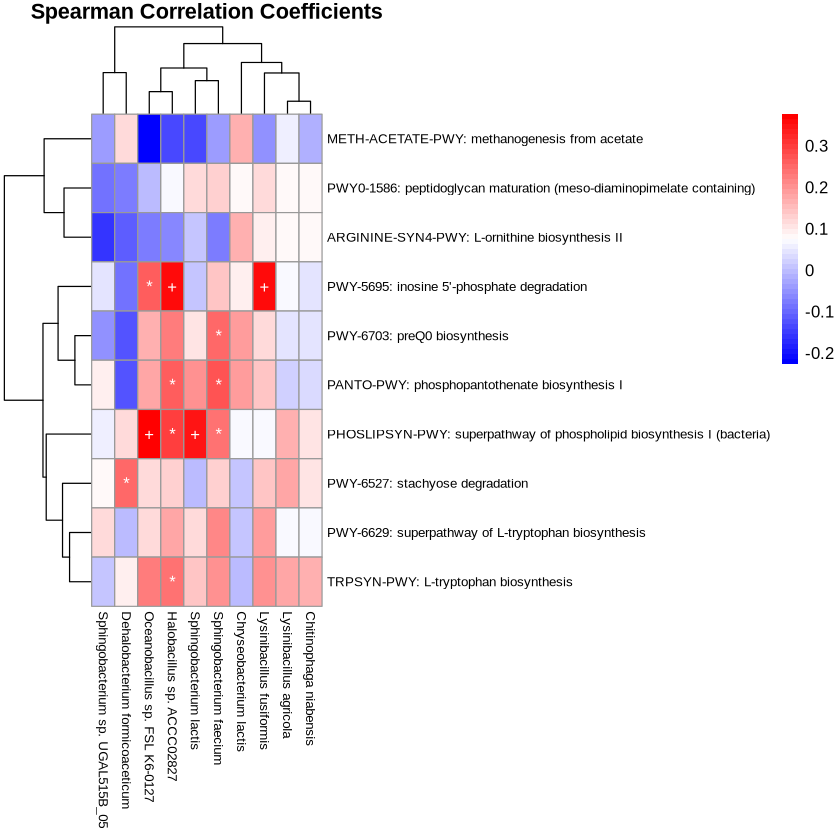

In [18]:
# Load the necessary package
if (!requireNamespace("pheatmap", quietly = TRUE)) {
  install.packages("pheatmap")
}
library(pheatmap)

# Step 2: Determine Significance (e.g., p-value < 0.05)
significance_matrix <- p_matrix < 0.05
marginal_matrix <- p_matrix < 0.01

# Prepare labels to mark significance
annotation_matrix <- matrix("", nrow = nrow(cor_matrix), ncol = ncol(cor_matrix))
annotation_matrix[significance_matrix] <- "*"  # Mark significant correlations with "*"
annotation_matrix[marginal_matrix] <- "+"

# Create a heatmap using pheatmap and add the annotation
pheatmap(cor_matrix,
         color = colorRampPalette(c("blue", "white", "red"))(50),
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         show_rownames = TRUE,
         show_colnames = TRUE,
         main = "Spearman Correlation Coefficients",
         fontsize_row = 8,
         fontsize_col = 8,
         display_numbers = annotation_matrix, # Add stars for significance
         number_color = "white",  # Color of the annotation text
         fontsize_number = 10)  # Size of the annotation text


In [19]:
clindat <- read.csv("/home/gamorten/Microbiome_Health/metadata/clincial_data.csv",  header = TRUE, stringsAsFactors = TRUE)
clindat$`Subject ID` <- clindat$Subject.ID
clindat$`Subject ID` <-as.factor(clindat$`Subject ID` )
clindat$Subject.ID<-NULL
head(clindat)
head(metadata)

,Stool_Count,Consent_EGA,Enroll_GA_From_REDCap,V1_EGA_Biometric,GDM,Hypertension,BMI,sysbp,diabp,heartrate,⋯,Delivery_EGA,CA_PretermLabor,PreTerm_Labor_EGA,StillBirth,Preeclampsia_During_Labor,Preeclampsia_At_PP,ca_ld_delivery_type,ca_ld_birth_weight,ca_ld_sex_of_baby,Subject ID
,<int>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<int>,<int>,<fct>,⋯,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,2,14.2857,14.2857,14.2857,No,No,24.64,112,69,72,⋯,40.0000,No,No,No,No,No,"Vaginal, spontaneous",3508,Female,HMC-01-1006
2,1,10.0000,10.0000,10.0000,No,Yes,23.21,121,81,80,⋯,36.1429,Yes,Yes,No,No,No,Unplanned cesarean section,2880,Female,HMC-01-1007
3,1,11.8571,11.8571,11.8571,No,No,23.42,105,67,80,⋯,39.0000,No,No,No,No,No,Scheduled cesarean section,3800,Female,HMC-01-1009
4,1,12.8571,12.8571,12.8571,No,Yes,34.42,136,80,88,⋯,37.0000,No,No,No,No,Yes,Scheduled cesarean section,2920,Female,HMC-01-1011
5,1,15.5714,15.5714,15.5714,No,No,35.20,109,57,78,⋯,39.5714,No,No,No,No,No,Scheduled cesarean section,3510,Male,HMC-01-1012
6,1,17.0000,17.0000,17.0000,No,Yes,30.21,136,77,67,⋯,39.2857,No,No,No,No,No,"Vaginal, spontaneous",3060,Female,HMC-01-1013


MBI Sample ID,Subject ID,Specimen ID,Sampling Date,Sample Type,Group,Race,Tobacco Use,BMI,Consent Age,⋯,Delivery_EGA,CA_PretermLabor,PreTerm_Labor_EGA,StillBirth,Preeclampsia_During_Labor,Preeclampsia_At_PP,ca_ld_delivery_type,ca_ld_birth_weight,ca_ld_sex_of_baby,Condition
<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
S00NO-0001,HMC-01-1006,4511679,4/18/2019,Human feces,Control,White,0,24.64,39,⋯,40.0000,No,No,No,No,No,"Vaginal, spontaneous",3508,Female,Healthy
S00NO-0002,HMC-01-2006,4589482,5/23/2019,Human feces,Case,Other,1,37.95,31,⋯,37.2857,Yes,No,No,Yes,No,"Vaginal, spontaneous",3160,Male,Hypertension
S00NO-0003,HMC-01-1032,4624890,6/14/2019,Human feces,Control,White,1,18.63,28,⋯,39.5714,No,No,No,No,No,"Vaginal, spontaneous",3340,Female,Healthy
S00NO-0004,HMC-01-1053,4663038,7/3/2019,Human feces,Control,White,1,27.29,37,⋯,37.2857,No,No,No,No,No,"Vaginal, spontaneous",2712,Female,Healthy
S00NO-0005,HMC-01-1074,4855634,10/8/2019,Human feces,Control,Other,1,20.85,34,⋯,37.4286,No,No,No,No,No,Unplanned cesarean section,3393,Male,Healthy
S00NO-0006,HMC-01-1072,4860125,10/9/2019,Human feces,Control,White,0,25.45,27,⋯,39.4286,No,No,No,No,No,"Vaginal, spontaneous",3081,Male,Healthy


In [20]:
merged_metadata <- merge(clindat, metadata, by = "Subject ID")
merged_metadata <- merge(merged_metadata, corr_input, by = "Subject ID")
head(merged_metadata)

,Subject ID,Stool_Count.x,Consent_EGA,Enroll_GA_From_REDCap,V1_EGA_Biometric,GDM.x,Hypertension.x,BMI.x,sysbp,diabp,⋯,Kingdom,Phylum,Class,Order,Family,Genus,Species,taxa_label,relative_abundance,Group.y
,<fct>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<int>,<int>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>,<dbl>,<fct>
1,HMC-01-1006,2,14.2857,14.2857,14.2857,No,No,24.64,112,69,⋯,Bacteria,Bacteroidota,Chitinophagia,Chitinophagales,Chitinophagaceae,Chitinophaga,niabensis,Chitinophaga niabensis,2.1509385,Control
2,HMC-01-1006,2,14.2857,14.2857,14.2857,No,No,24.64,112,69,⋯,Bacteria,Bacteroidota,Chitinophagia,Chitinophagales,Chitinophagaceae,Chitinophaga,niabensis,Chitinophaga niabensis,2.1509385,Control
3,HMC-01-1006,2,14.2857,14.2857,14.2857,No,No,24.64,112,69,⋯,Bacteria,Bacteroidota,Sphingobacteriia,Sphingobacteriales,Sphingobacteriaceae,Sphingobacterium,sp. UGAL515B_05,Sphingobacterium sp. UGAL515B_05,0.6113763,Control
4,HMC-01-1006,2,14.2857,14.2857,14.2857,No,No,24.64,112,69,⋯,Bacteria,Bacillota,Bacilli,Bacillales,Bacillaceae,Halobacillus,sp. ACCC02827,Halobacillus sp. ACCC02827,2.8326275,Control
5,HMC-01-1006,2,14.2857,14.2857,14.2857,No,No,24.64,112,69,⋯,Bacteria,Bacillota,Bacilli,Bacillales,Bacillaceae,Lysinibacillus,agricola,Lysinibacillus agricola,2.5961544,Control
6,HMC-01-1006,2,14.2857,14.2857,14.2857,No,No,24.64,112,69,⋯,Bacteria,Bacteroidota,Flavobacteriia,Flavobacteriales,Weeksellaceae,Chryseobacterium,lactis,Chryseobacterium lactis,1.9322760,Control


In [21]:
colnames(merged_metadata)

[1] "Subject ID"                  "Stool_Count.x"              
 [3] "Consent_EGA"                 "Enroll_GA_From_REDCap"      
 [5] "V1_EGA_Biometric"            "GDM.x"                      
 [7] "Hypertension.x"              "BMI.x"                      
 [9] "sysbp"                       "diabp"                      
[11] "heartrate"                   "matbio_lab_hba1c_result"    
[13] "matbio_lab_fructos"          "matbio_lab_cholest"         
[15] "matbio_lab_trigly"           "matbio_lab_hdl"             
[17] "matbio_lab_ldl"              "matbio_lab_totalchol"       
[19] "matbio_lab_glucose_value"    "Delivery_EGA.x"             
[21] "CA_PretermLabor.x"           "PreTerm_Labor_EGA.x"        
[23] "StillBirth.x"                "Preeclampsia_During_Labor.x"
[25] "Preeclampsia_At_PP.x"        "ca_ld_delivery_type.x"      
[27] "ca_ld_birth_weight.x"        "ca_ld_sex_of_baby.x"        
[29] "MBI Sample ID"               "Specimen ID.x"              
[31] "Sampling Date.x"             "Sample Type.x"              
[33] "Group"                       "Race.x"                     
[35] "Tobacco Use.x"               "BMI.y"                      
[37] "Consent Age.x"               "Visit.x"                    
[39] "Batch.x"                     "Stool_Count.y"              
[41] "GDM.y"                       "Hypertension.y"             
[43] "Delivery_EGA.y"              "CA_PretermLabor.y"          
[45] "PreTerm_Labor_EGA.y"         "StillBirth.y"               
[47] "Preeclampsia_During_Labor.y" "Preeclampsia_At_PP.y"       
[49] "ca_ld_delivery_type.y"       "ca_ld_birth_weight.y"       
[51] "ca_ld_sex_of_baby.y"         "Condition"                  
[53] "Sample"                      "Pathway"                    
[55] "Abundance"                   "Specimen ID.y"              
[57] "Sampling Date.y"             "Sample Type.y"              
[59] "Group.x"                     "Race.y"                     
[61] "Tobacco Use.y"               "BMI"                        
[63] "Consent Age.y"               "Visit.y"                    
[65] "Batch.y"                     "Stool_Count"                
[67] "GDM"                         "Hypertension"               
[69] "Delivery_EGA"                "CA_PretermLabor"            
[71] "PreTerm_Labor_EGA"           "StillBirth"                 
[73] "Preeclampsia_During_Labor"   "Preeclampsia_At_PP"         
[75] "ca_ld_delivery_type"         "ca_ld_birth_weight"         
[77] "ca_ld_sex_of_baby"           "OTU"                        
[79] "baseMean"                    "log2FoldChange"             
[81] "lfcSE"                       "stat"                       
[83] "pvalue"                      "padj"                       
[85] "Kingdom"                     "Phylum"                     
[87] "Class"                       "Order"                      
[89] "Family"                      "Genus"                      
[91] "Species"                     "taxa_label"                 
[93] "relative_abundance"          "Group.y"

In [26]:
# Load necessary libraries
library(dplyr)

df <- merged_metadata

# Separate Control and Case groups
control_group <- df %>% filter(Group == "Control")
case_group <- df %>% filter(Group == "Case")

# Initialize a data frame to store results
results <- data.frame(
  Variable = character(),
  Control_Range = character(),
  Case_Range = character(),
  P_value = numeric(),
  stringsAsFactors = FALSE
)

# Loop through each numeric column
for (col in names(df)[sapply(df, is.numeric)]) {
  # Calculate ranges for Control and Case groups
  control_range <- range(control_group[[col]], na.rm = TRUE)
  case_range <- range(case_group[[col]], na.rm = TRUE)
  
  # Perform t-test (assuming equal variance = FALSE)
  t_test <- wilcox.test(control_group[[col]], case_group[[col]])
  
  # Store the results in the data frame
  results <- rbind(results, data.frame(
    Variable = col,
    Control_Range = paste(control_range, collapse = " - "),
    Case_Range = paste(case_range, collapse = " - "),
    P_value = t_test$p.value
  ))
}

# Save the results
write.csv(results, "/home/gamorten/Microbiome_Health/data/metadata_p_values.csv", row.names = FALSE)

Warning message:
“There were 13 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(everything(), ~as.numeric(as.character(.)))`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 12 remaining warnings.”
Warning message in cor.test.default(combined_data_numeric[[i]], combined_data_numeric[[clinical_cols + :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(combined_data_numeric[[i]], combined_data_numeric[[clinical_cols + :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(combined_data_numeric[[i]], combined_data_numeric[[clinical_cols + :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(combined_data_numeric[[i]], combined_data_numeric[[clinical_cols + :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(combined_data_numeric[[i]], combined_data_numeric[[clinical_cols + :
“Cannot compute exact p-value with ties”
Wa

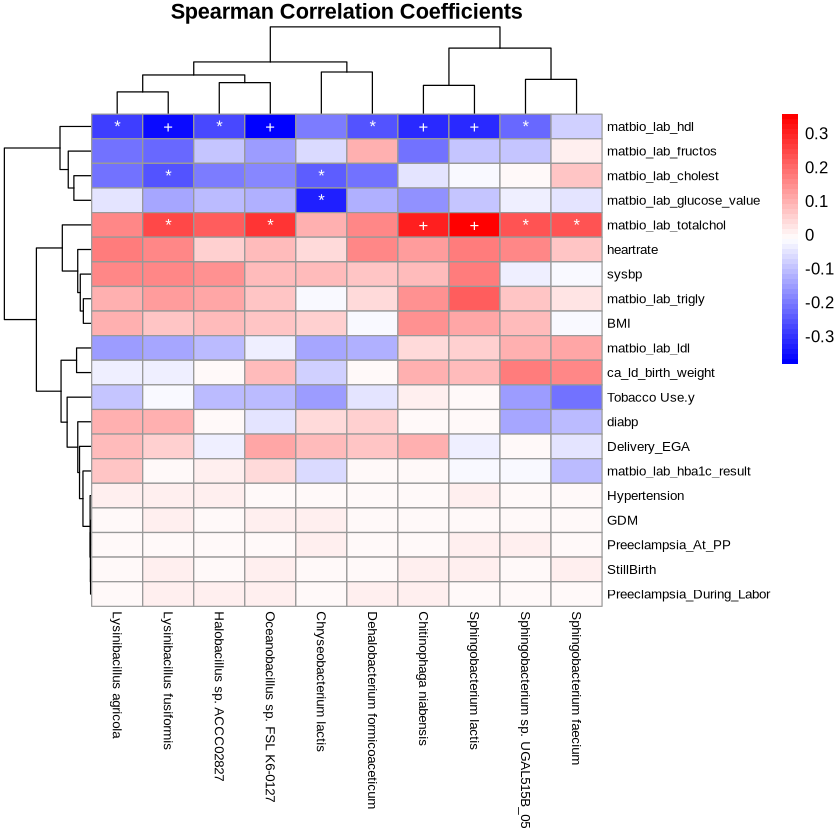

In [56]:
# Load necessary libraries
library(dplyr)
library(tidyr)
library(pheatmap)
library(Hmisc)  # For the rcorr() function

# Assuming your original data frame is called df

# Step 1: Convert taxa data to wide format
# Assuming df has columns: "Sample", "taxa_label", "relative_abundance"
taxa_data_wide <- df %>%
  select(Sample, taxa_label, relative_abundance) %>%
  # Pivot to a wide format with taxa labels as columns and relative abundance as values
  pivot_wider(
    id_cols = Sample, # Make sure each row is unique for each sample
    names_from = taxa_label,
    values_from = relative_abundance,
    values_fn = sum,
    values_fill = list(relative_abundance = 0)  # Corrected: Use a list to specify the fill value correctly
  )

# Step 2: Select clinical columns and ensure they are matched by Sample
clinical_data <- df %>%
  select(
    Sample,
    matches("^(sysbp|diabp|heartrate)$"),
    matches("^(matbio_lab_hba1c_result|matbio_lab_fructos|matbio_lab_cholest|matbio_lab_trigly|matbio_lab_hdl|matbio_lab_ldl|matbio_lab_totalchol|matbio_lab_glucose_value)?$"),
    matches("^(GDM|Hypertension)?$"),
    matches("^(Delivery_EGA|StillBirth|Preeclampsia_During_Labor|Preeclampsia_At_PP|ca_ld_birth_weight)?$"),
    matches("^(BMI)?$"),
    matches("^(Tobacco Use)(\\.y)?$")
  ) %>%
  distinct()  # Make sure clinical data is unique for each sample

# Step 3: Join clinical and taxa data by Sample
combined_data <- clinical_data %>%
  inner_join(taxa_data_wide, by = "Sample")  # Join by "Sample" to align rows correctly

# Step 4: Ensure both clinical and taxa data are numeric (excluding Sample column)
combined_data_numeric <- combined_data %>%
  select(-Sample) %>%
  mutate(across(everything(), ~ as.numeric(as.character(.))))

# Initialize empty matrices for correlation values and p-values
clinical_cols <- ncol(clinical_data) - 1  # -1 to exclude Sample
taxa_cols <- ncol(taxa_data_wide) - 1  # -1 to exclude Sample
correlation_matrix <- matrix(NA, nrow = clinical_cols, ncol = taxa_cols)
p_matrix <- matrix(NA, nrow = clinical_cols, ncol = taxa_cols)  # Matrix to store p-values
rownames(correlation_matrix) <- colnames(clinical_data)[-1]  # Exclude "Sample"
colnames(correlation_matrix) <- colnames(taxa_data_wide)[-1]  # Exclude "Sample"
rownames(p_matrix) <- colnames(clinical_data)[-1]
colnames(p_matrix) <- colnames(taxa_data_wide)[-1]

# Step 5: Loop through each clinical variable and each taxon to calculate the correlation
for (i in 1:clinical_cols) {
  for (j in 1:taxa_cols) {
    # Check if both columns have enough valid data points for correlation
    if (sum(!is.na(combined_data_numeric[[i]])) > 1 && sum(!is.na(combined_data_numeric[[clinical_cols + j]])) > 1) {
      # Calculate the Spearman correlation between clinical variable and taxon
      cor_result <- cor.test(combined_data_numeric[[i]], combined_data_numeric[[clinical_cols + j]], use = "pairwise.complete.obs", method = "spearman")
      correlation_matrix[i, j] <- cor_result$estimate
      p_matrix[i, j] <- cor_result$p.value
    } else {
      # If not enough valid data points, store NA
      correlation_matrix[i, j] <- NA
      p_matrix[i, j] <- NA
    }
  }
}

# Step 6: Handle NA values in the correlation matrix to avoid errors in heatmap clustering
# Replace NA with a small random value to introduce variation or use a very small constant value
correlation_matrix[is.na(correlation_matrix)] <- runif(sum(is.na(correlation_matrix)), min = -0.01, max = 0.01)

# Step 7: Create a custom set of color breaks for pheatmap to ensure uniqueness
min_val <- min(correlation_matrix, na.rm = TRUE)
max_val <- max(correlation_matrix, na.rm = TRUE)
breaks <- seq(min_val, max_val, length.out = 51)  # Define custom breaks

# Step 8: Determine Significance (e.g., p-value < 0.05)
significance_matrix <- p_matrix < 0.05
marginal_matrix <- p_matrix < 0.01

# Step 9: Prepare labels to mark significance
annotation_matrix <- matrix("", nrow = nrow(correlation_matrix), ncol = ncol(correlation_matrix))
annotation_matrix[significance_matrix] <- "*"  # Mark significant correlations with "*"
annotation_matrix[marginal_matrix] <- "+"      # Mark more significant correlations with "+"

pheatmap(correlation_matrix,
         color = colorRampPalette(c("blue", "white", "red"))(50),
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         show_rownames = TRUE,
         show_colnames = TRUE,
         main = "Spearman Correlation Coefficients",
         fontsize_row = 8,
         fontsize_col = 8,
         display_numbers = annotation_matrix, # Add stars for significance
         number_color = "white",  # Color of the annotation text
         fontsize_number = 10)  # Size of the annotation text
